# 📘 Técnicas de Encoding Quântico e Carregamento de Dados

<div align="center">

![Quantum Computing](https://img.shields.io/badge/Quantum-Computing-8A2BE2?style=for-the-badge&logo=quantum&logoColor=white)
![Python](https://img.shields.io/badge/Python-3.10+-3776AB?style=for-the-badge&logo=python&logoColor=white)
![Jupyter](https://img.shields.io/badge/Jupyter-Notebook-F37626?style=for-the-badge&logo=jupyter&logoColor=white)

</div>

> Este notebook apresenta exemplos práticos sobre técnicas de **encoding quântico** e **carregamento de dados**, com foco no processamento de imagens.

Os exemplos utilizam o dataset **MNIST**, amplamente usado em tarefas de classificação de dígitos manuscritos, disponível via Keras (TensorFlow).

---

# Conteúdo

1. [Configuração Inicial](#Configuração-Inicial)  
   - [Dataset: MNIST](#Dataset:-MNIST)  
   - [Redução de dimensionalidade (block averaging)](#Redução-de-dimensionalidade-(block-averaging))  
   - [Normalize features using z-score standardization](#Normalize-features-using-z-score-standardization)

2. [Binary Preprocessor](#Binary-Preprocessor)  
   - [Visualização do processo](#Visualização-do-processo)

3. [Encoding por Superposição com Amplitude Encoding](#Encoding-por-Superposição-com-Amplitude-Encoding)

4. [Preparação de Estados Arbitrários para Codificação por Amplitude](#Preparação-de-Estados-Arbitrários-para-Codificação-por-Amplitude)

5. [Preparação de Estados Eficiente em Qubits](#Preparação-de-Estados-Eficiente-em-Qubits)

6. [Codificação de Entradas como Evoluções no Tempo](#Codificação-de-Entradas-como-Evoluções-no-Tempo)

7. [Codificação de um Conjunto de Dados via Hamiltoniano](#Codificação-de-um-Conjunto-de-Dados-via-Hamiltoniano)

8. [Simulação de Hamiltonianos Eficiente em Qubits](#Simulação-de-Hamiltonianos-Eficiente-em-Qubits)

9. [Exponenciação da Matriz Densidade](#Exponenciação-da-Matriz-Densidade)

10. [Codificação de Dados como um Mapa de Características](#Codificação-de-Dados-como-um-Mapa-de-Características)

---

<a id="configuracao-inicial"></a>
# 1. Configuração Inicial



O PennyLane utiliza uma versão customizada do NumPy que permite a diferenciação automática, essencial para Quantum Machine Learning.

Com o Qiskit moderno, a biblioteca Aer é o motor de simulação local.

In [ ]:
!pip install -qq -U "classiq[qml]"
!pip install qiskit pylatexenc qiskit-aer matplotlib atlas_mpl_style pennylane pennylane-qiskit -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 684.2/684.2 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 1.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 23.2 which is incompatible.
wheel 0.46.3 requires pac

In [ ]:
import pennylane as qml
from pennylane import numpy as np
from pennylane.math import requires_grad
from pennylane.templates import RandomLayers
import tensorflow as tf
from tensorflow import keras
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.visualization import plot_histogram, plot_bloch_multivector
from qiskit.quantum_info import Statevector, SparsePauliOp, Operator
from sklearn.preprocessing import StandardScaler, Binarizer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import torch

%matplotlib inline

In [ ]:
N_EPOCHS = 30
N_LAYERS = 1
N_TRAIN = 50
N_TEST = 30
N_QUBITS = 4
N_FEATURES = N_QUBITS
SAVE_PATH = "_static"
PREPROCESS = True
np.random.seed(42)
tf.random.set_seed(0)

<a id="dataset-mnist"></a>
## 1.1 Dataset: MNIST

---


O MNIST contém imagens de dígitos de 0 a 9 com as seguintes características:

- Imagens em escala de cinza de **28 × 28 pixels**
- Valores de pixel no intervalo **[0, 255]**


## Etapas de Pré-processamento

Antes de aplicar modelos clássicos ou quânticos, os dados passam por algumas etapas essenciais.

## Explicação

> Esta função realiza três tarefas principais:
>
> 1. **Carrega** o dataset MNIST usando Keras
> 2. **Seleciona** um subconjunto dos dados (útil para testes rápidos)
> 3. **Normaliza** os pixels para o intervalo `[0, 1]`

**Isso melhora** a estabilidade numérica e o desempenho dos modelos.

### 1. Carregamento e normalização dos dados
---

In [ ]:
def load_mnist_data(n_train, n_test):
    mnist = keras.datasets.mnist
    (train_images, train_labels), (test_images, test_labels) = mnist.load_data()
    # Subset the data
    train_images = train_images[:n_train]
    train_labels = train_labels[:n_train]
    test_images = test_images[:n_test]
    test_labels = test_labels[:n_test]
    # Normalize pixel values
    train_images = train_images / 255.0
    test_images = test_images / 255.0
    return (train_images, train_labels), (test_images, test_labels)

<a id="reducao-dimensionalidade"></a>
## 1.2 Redução de dimensionalidade (block averaging)

---

### Explicação

> Esta função reduz a dimensionalidade das imagens usando **média por blocos**:
>
> - A imagem original (`28×28`) é dividida em uma grade menor
> - Cada bloco é substituído pela **média** dos seus pixels
> - O resultado é um vetor com **menos características**

### Exemplo

> Se `n_features = 16`:
>
> ```
> A imagem vira uma grade 4×4
> Cada bloco tem 7×7 pixels
> Resultado final: vetor de 16 valores
> ```

### Por que isso é importante?

> - Reduz **custo computacional**
> - Remove **ruído**
> - Facilita o uso em **algoritmos quânticos** (menos qubits necessários)
---

In [ ]:
def reduce_dimensionality(images, n_features):
    n_images = len(images)
    reduced = np.zeros((n_images, n_features))
    grid_size = int(np.sqrt(n_features))
    block_size = 28 // grid_size

    for i in range(n_images):
        img = images[i].reshape(28, 28)
        for j in range(n_features):
            row = (j // grid_size) * block_size
            col = (j % grid_size) * block_size
            block = img[row:row+block_size, col:col+block_size]
            reduced[i, j] = np.mean(block)

    return reduced

<a id="normalize-features"></a>
## 1.3 Normalize features using z-score standardization

---



## Explicação

> Aplica a **padronização Z-score**, transformando os dados para:
>
> - **Média = 0**
> - **Desvio padrão = 1**

### Fórmula
$$
z = \frac{(x - μ)}{σ}
$$
Onde:

- `x`: valor original
- `μ`: média
- `σ`: desvio padrão

### Modos de uso

> - **Treino**: calcula média e desvio padrão
> - **Teste**: reutiliza os mesmos valores (consistência)

### Importância

> - Evita que algumas *features* dominem o modelo
> - Melhora a **convergência**
> - Essencial para **ML** e **quantum ML**
> - ---

In [ ]:
def normalize_features(images, fit_stats=None):
    if fit_stats is None:
        # Fit and transform
        mean = np.mean(images, axis=0)
        std = np.std(images, axis=0)
        normalized = (images - mean) / std
        return normalized, (mean, std)
    else:
        # Transform using existing stats
        mean, std = fit_stats
        return (images - mean) / std

<a id="binary-preprocessor"></a>
# 2. Binary Preprocessor

---
## Pré-processamento para Encoding Binário em Circuitos Quânticos

> Nesta seção, implementamos um pipeline completo de pré-processamento de imagens do MNIST com o objetivo de prepará-las para **binary basis encoding** em circuitos quânticos.

A ideia principal é transformar imagens em **vetores binários (0 e 1)** que possam ser diretamente interpretados como estados quânticos.

## Classe BinaryPreprocessor

### Explicação

> Esta classe organiza todo o pipeline de pré-processamento:
>
> - `n_features`: número final de características (dimensão reduzida)
> - `StandardScaler`: normaliza os dados (Z-score)
> - `PCA`: reduz dimensionalidade e remove correlações
> - `Binarizer`: transforma valores contínuos em binários

Em computação quântica, é comum usar dimensões que sejam **potências de 2** (ex: 2, 4, 8, 16), pois isso se alinha com o número de qubits.

---

##  Método preprocess

###  Explicação passo a passo

#### 1. Redução de dimensionalidade

> Usa a função `reduce_dimensionality` (média por blocos)
> Converte imagem `28×28` em um vetor menor

-> Isso reduz o número de variáveis e facilita o encoding quântico

#### 2. PCA (Principal Component Analysis)

> - Reduz ainda mais a dimensionalidade
> - Remove redundância entre features
> - Ordena componentes por importância

-> Resultado: `dados mais compactos e informativos`

#### 3. Normalização (StandardScaler)

> Aplica Z-score:
> - `média = 0`
> - `desvio padrão = 1`

-> Garante que todas as features tenham a mesma escala

#### 4. Binarização

> Transforma valores contínuos em **bits (0 ou 1)**.
---

In [ ]:
class BinaryPreprocessor:
    def __init__(self, n_features=8, binarization_method='threshold'):
        self.n_features = n_features
        self.binarization_method = binarization_method
        self.scaler = StandardScaler()
        self.pca = PCA(n_components=n_features)
        self.binarizer = Binarizer(threshold=0.5)
        self.normalization_stats = None
        valid_methods = {'threshold', 'random', 'pca_binary'}
        if binarization_method not in valid_methods:
            raise ValueError(f"Unknown binarization method: {binarization_method}")
    def preprocess(self, X, fit=True):
        X_reduced = reduce_dimensionality(X, self.n_features)
        transform_func = self.pca.fit_transform if fit else self.pca.transform
        X_pca = transform_func(X_reduced)
        scale_func = self.scaler.fit_transform if fit else self.scaler.transform
        X_scaled = scale_func(X_pca)
        binarization_methods = {
            'threshold': lambda x: (x > 0).astype(int),
            'random': lambda x: (np.random.random(x.shape) < 1/(1+np.exp(-x))).astype(int),
            'pca_binary': lambda x: self.binarizer.fit_transform(x)
        }
        return binarization_methods[self.binarization_method](X_scaled)
    def visualize_binarization(self, X_original, labels, idx=0):
        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        self._plot_original_image(axes[0], X_original[idx], labels[idx])
        self._plot_reduced_features(axes[1], X_original[idx:idx+1])
        X_reduced_all = reduce_dimensionality(X_original, self.n_features)
        X_pca = self.pca.fit_transform(X_reduced_all)
        X_scaled = self.scaler.fit_transform(X_pca)
        self._plot_pca_features(axes[2], X_scaled[idx])
        X_binary = self.preprocess(X_original, fit=True)
        self._plot_binary_features(axes[3], X_binary[idx])
        plt.tight_layout()
        plt.show()
        self._print_binary_info(X_binary[idx])
        return X_binary[idx]
    def _plot_original_image(self, ax, image, label):
        ax.imshow(image.reshape(28, 28), cmap='gray')
        ax.set_title(f'Original Image\nLabel: {label}')
        ax.axis('off')
    def _plot_reduced_features(self, ax, sample):
        reduced_img = reduce_dimensionality(sample, self.n_features)[0]
        size = int(np.sqrt(self.n_features))
        reduced_vis = reduced_img.reshape(size, size)
        ax.imshow(reduced_vis, cmap='gray')
        ax.set_title(f'Reduced Features\n{size}x{size} grid')
        ax.axis('off')
    def _plot_pca_features(self, ax, features):
        ax.bar(range(self.n_features), features)
        ax.set_title(f'PCA Features (Scaled)\nn_features={self.n_features}')
        ax.set_xlabel('Feature Index')
        ax.set_ylabel('Value')
        ax.grid(True, alpha=0.3)
    def _plot_binary_features(self, ax, binary_features):
        ax.bar(range(self.n_features), binary_features)
        ax.set_title(f'Binary Features\nMethod: {self.binarization_method}')
        ax.set_xlabel('Bit Index')
        ax.set_ylabel('Bit Value (0/1)')
        ax.set_ylim([-0.1, 1.1])
        ax.grid(True, alpha=0.3)
    def _print_binary_info(self, binary_features):
        print(f"Binary features: {binary_features}")
        print(f"Number of 1s: {np.sum(binary_features)}/{self.n_features}")

<a id="visualizacao-processo"></a>
## 2.1 Visualização do processo

---

### O que é mostrado?

> A função gera **4 visualizações lado a lado**:

| # | Visualização | Descrição                                                                                                    |
|---|--------------|--------------------------------------------------------------------------------------------------------------|
| 1️⃣ | **Imagem original** | Mostra a imagem MNIST original (`28×28`)<br>Inclui o rótulo (dígito real)                                    |
| 2️⃣ | **Imagem reduzida** | Após block averaging<br>Representada como uma grade menor<br>-> Permite ver como a informação foi comprimida |
| 3️⃣ | **Features após PCA + normalização** | Gráfico de barras<br>Cada barra = uma feature<br>-> Mostra valores contínuos antes da binarização            |
| 4️⃣ | **Features binárias** | Vetor final de 0s e 1s<br>`Pronto para uso em circuitos quânticos`                                           |

---

## Saída adicional

> A função também imprime:
>
> - `O vetor binário final`
> - `Quantidade de bits iguais a 1`

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

Binary data shape: (50, 4)

Sample binary features (first 5 images):
Image 0: [1 1 1 1] (label: 5)
Image 1: [1 0 0 1] (label: 0)
Image 2: [0 1 1 0] (label: 4)
Image 3: [0 0 1 0] (label: 1)
Image 4: [0 1 0 0] (label: 9)


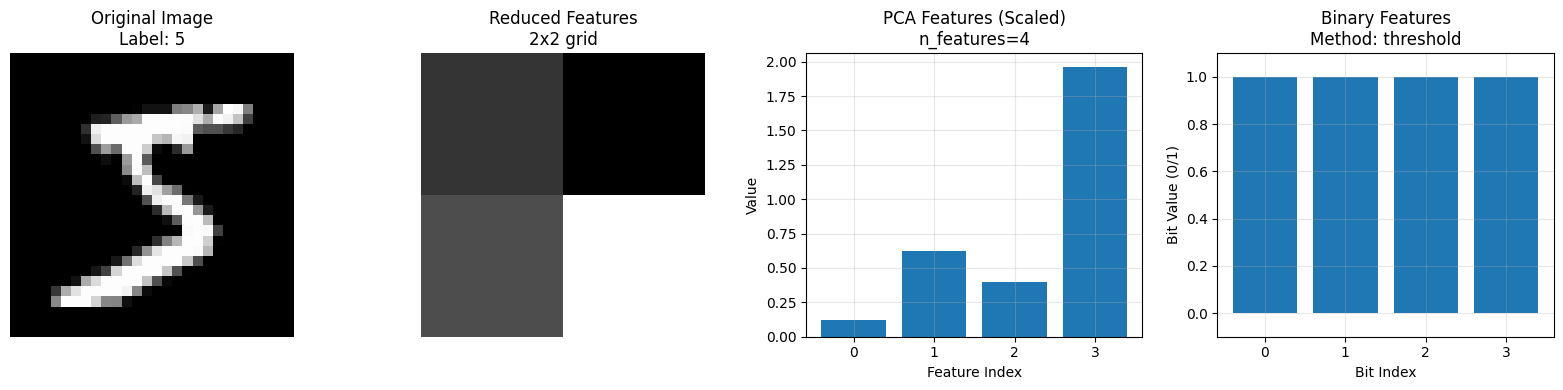

Binary features: [1 1 1 1]
Number of 1s: 4/4


array([1, 1, 1, 1])

In [ ]:
(train_images, train_labels), _ = load_mnist_data(N_TRAIN, N_TEST)
preprocessor = BinaryPreprocessor(
        n_features=N_FEATURES,
        binarization_method='threshold'
    )
X_binary = preprocessor.preprocess(train_images, fit=True)

print(f"\nBinary data shape: {X_binary.shape}")
print("\nSample binary features (first 5 images):")
for i in range(5):
    print(f"Image {i}: {X_binary[i]} (label: {train_labels[i]})")

preprocessor.visualize_binarization(train_images, train_labels, idx=0)


Binary data shape: (50, 16)

Sample binary features (first 5 images):
Image 0: [1 1 0 0 0 0 1 0 0 1 1 1 1 1 1 1] (label: 5)
Image 1: [1 0 1 0 0 1 1 1 1 1 1 0 0 1 0 0] (label: 0)
Image 2: [0 1 1 1 0 0 1 1 0 1 0 1 0 0 0 0] (label: 4)
Image 3: [0 0 1 1 0 0 0 0 1 1 0 0 1 0 1 1] (label: 1)
Image 4: [0 1 0 1 1 1 0 0 0 0 0 1 1 0 1 0] (label: 9)


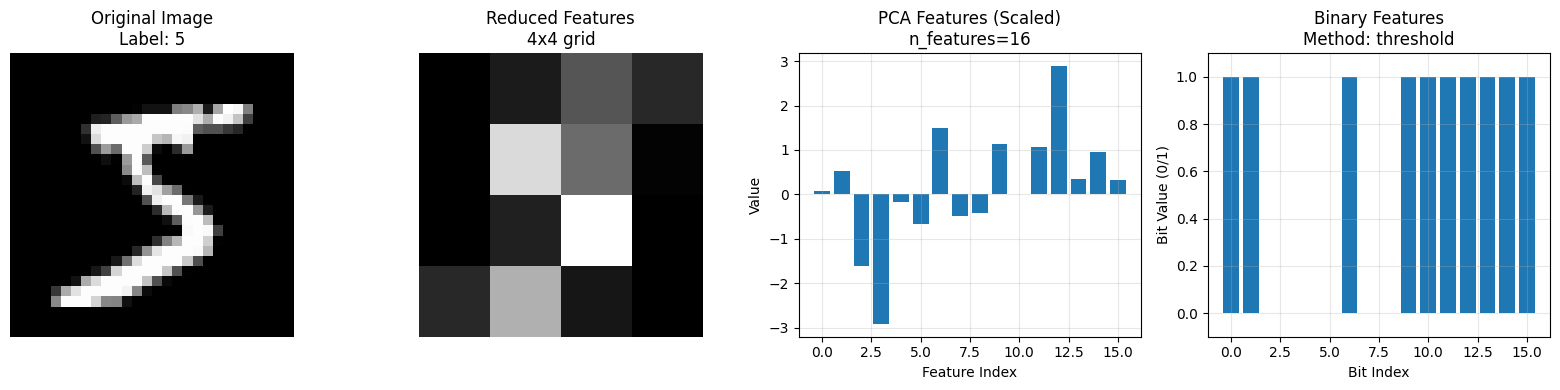

Binary features: [1 1 0 0 0 0 1 0 0 1 1 1 1 1 1 1]
Number of 1s: 10/16


array([1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
(train_images, train_labels), _ = load_mnist_data(N_TRAIN, N_TEST)
preprocessor = BinaryPreprocessor(
        n_features=16,
        binarization_method='threshold'
    )
X_binary = preprocessor.preprocess(train_images, fit=True)

print(f"\nBinary data shape: {X_binary.shape}")
print("\nSample binary features (first 5 images):")
for i in range(5):
    print(f"Image {i}: {X_binary[i]} (label: {train_labels[i]})")

preprocessor.visualize_binarization(train_images, train_labels, idx=0)

# Encoding por Superposição com Amplitude Encoding


> Nesta seção, implementamos um encoder quântico que prepara uma **superposição de padrões binários** usando **Amplitude Encoding**.

A ideia central é representar **múltiplos padrões binários simultaneamente** em um único estado quântico.

---

## Conceito Fundamental

> O estado preparado é:

$$
|ψ⟩ = (1/√M) Σ |pattern⟩
$$


**Onde:**

- `M`: número de padrões
- `|pattern⟩`: estados base (ex: |010⟩, |111⟩)

-> `Todos os padrões têm a mesma probabilidade`

---

## Importância para Computação Quântica

> - `Permite paralelismo quântico` (processar múltiplos padrões simultaneamente)
> - `Reduz número de operações` em algoritmos como Grover ou QML
> - `Base para modelos híbridos` de aprendizado de máquina quântico


---


## Classe SuperpositionEncoder

> Esta classe permite:
>
> - `Converter padrões binários` em um vetor de amplitudes
> - `Preparar um estado quântico` em superposição
> - `Medir probabilidades`
> - `Visualizar o resultado`

---

## Explicação

> - `n_qubits`: número de qubits do sistema
> - `qml.device`: simulador quântico (PennyLane)

 O número de estados possíveis é:
$$
2^n
$$


**Exemplo:**

- `3 qubits → 8 estados possíveis` (|000⟩ até |111⟩)

---

## Conversão para vetor de amplitudes

### O que faz?

> Converte padrões binários em um **vetor de amplitudes** que representa um estado quântico.

### Passo a passo

#### 1. Inicializa vetor vazio
#### 2. Mapeia cada padrão para um índice
#### 3. Marca presença no vetor
#### 4. Normalização


In [ ]:
class SuperpositionEncoder:
    def __init__(self, n_qubits):
        self.n = n_qubits
        self.dev = qml.device('default.qubit', wires=n_qubits)

    def patterns_to_amplitude_vector(self, patterns):
        n_states = 2 ** self.n
        amplitude_vector = np.zeros(n_states, dtype=complex)

        for pattern in patterns:
            pattern_str = ''.join(str(int(bit)) for bit in pattern)
            idx = int(pattern_str, 2)
            amplitude_vector[idx] = 1.0

        norm = np.linalg.norm(amplitude_vector)
        if norm > 0:
            amplitude_vector = amplitude_vector / norm

        return amplitude_vector

    def prepare_superposition(self, patterns):
        amplitude_vector = self.patterns_to_amplitude_vector(patterns)

        @qml.qnode(self.dev)
        def circuit():
            qml.AmplitudeEmbedding(
                features=amplitude_vector,
                wires=range(self.n),
                normalize=True
            )
            return qml.state()

        return circuit

    def get_probabilities(self, patterns):
        circuit = self.prepare_superposition(patterns)
        state = circuit()

        probabilities = {}
        expected = 1.0 / len(patterns) if patterns else 0

        for pattern in patterns:
            pattern_str = ''.join(str(int(bit)) for bit in pattern)
            idx = int(pattern_str, 2)
            prob = float(np.abs(state[idx]) ** 2)
            probabilities[pattern_str] = prob

        return probabilities, expected

    def visualize(self, patterns, title=None):
        if not patterns:
            print("No patterns to visualize.")
            return

        print(f"\n{'='*50}")
        if title:
            print(title)
        else:
            print(f"SUPERPOSITION OF {len(patterns)} PATTERNS")
        print(f"{'='*50}")

        print("\nEncoded patterns:")
        for i, p in enumerate(patterns):
            pattern_str = ''.join(str(int(bit)) for bit in p)
            print(f"   {i+1}. |{pattern_str}⟩")

        probabilities, expected = self.get_probabilities(patterns)

        print(f"\nProbabilities:")
        total = 0
        for pattern, prob in probabilities.items():
            total += prob
            status = "" if abs(prob - expected) < 0.01 else "⚠️"
            print(f"   {status} |{pattern}⟩: {prob:.4f} (expected: {expected:.4f})")

        print(f"\nTotal probability in patterns: {total:.4f}")

        if total > 0.99:
            print("\nSUCCESS! Superposition prepared correctly.")
        else:
            print("\nWARNING: Probability not fully concentrated on patterns.")

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        labels = list(probabilities.keys())
        theoretical = [expected] * len(labels)
        quantum = [probabilities[l] for l in labels]
        axes[0].bar(range(len(labels)), theoretical, color='skyblue', edgecolor='black')
        axes[0].set_xticks(range(len(labels)))
        axes[0].set_xticklabels([f"|{l}⟩" for l in labels], rotation=45, ha='right')
        axes[0].set_ylabel('Probability')
        axes[0].set_title(f'Theoretical (1/{len(patterns)})')
        axes[0].set_ylim([0, 1])
        axes[0].grid(False)
        bars = axes[1].bar(range(len(labels)), quantum, color='lightcoral', edgecolor='black')
        axes[1].set_xticks(range(len(labels)))
        axes[1].set_xticklabels([f"|{l}⟩" for l in labels], rotation=45, ha='right')
        axes[1].set_ylabel('Probability')
        axes[1].set_title('Actual Quantum State')
        axes[1].set_ylim([0, 1])
        axes[1].grid(False)
        for bar, prob in zip(bars, quantum):
            axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                        f'{prob:.3f}', ha='center', va='bottom')

        title_text = title or f'Superposition of {len(patterns)} Patterns\n|ψ⟩ = (1/√{len(patterns)}) Σ |pattern⟩'
        plt.suptitle(title_text, fontweight='bold')
        plt.tight_layout()
        plt.show()


MNIST data prepared: 5 samples
Each image reduced to 4 bits


Unique patterns found in MNIST:
   |0.01.01.00.0⟩ (digit: 0)

Total unique patterns found: 1

Total unique patterns found: 1
   |0.01.00.01.0⟩ (digit: 1)

Total unique patterns found: 2

Superposition of 2 MNIST Patterns

Encoded patterns:
   1. |0110⟩
   2. |0101⟩

Probabilities:
    |0110⟩: 0.5000 (expected: 0.5000)
    |0101⟩: 0.5000 (expected: 0.5000)

Total probability in patterns: 1.0000

SUCCESS! Superposition prepared correctly.


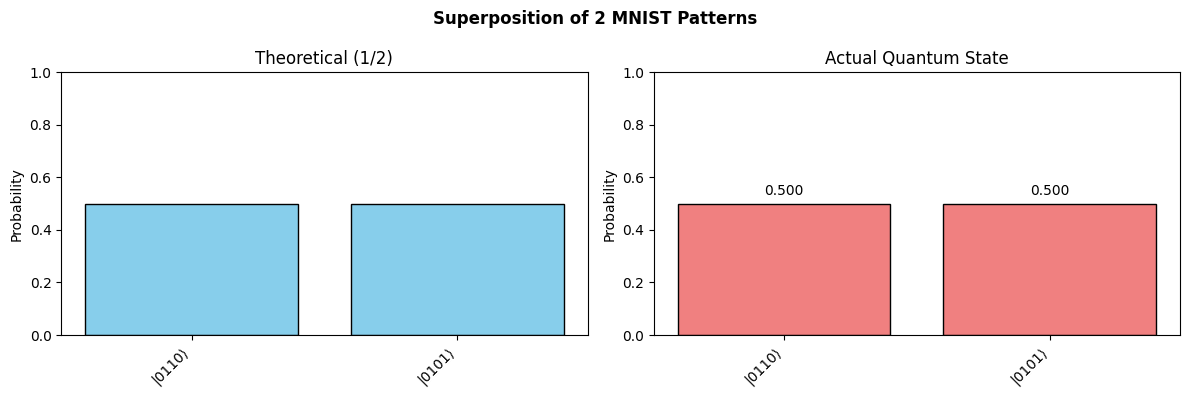


Total unique patterns found: 2

Superposition of 2 MNIST Patterns

Encoded patterns:
   1. |0110⟩
   2. |0101⟩

Probabilities:
    |0110⟩: 0.5000 (expected: 0.5000)
    |0101⟩: 0.5000 (expected: 0.5000)

Total probability in patterns: 1.0000

SUCCESS! Superposition prepared correctly.


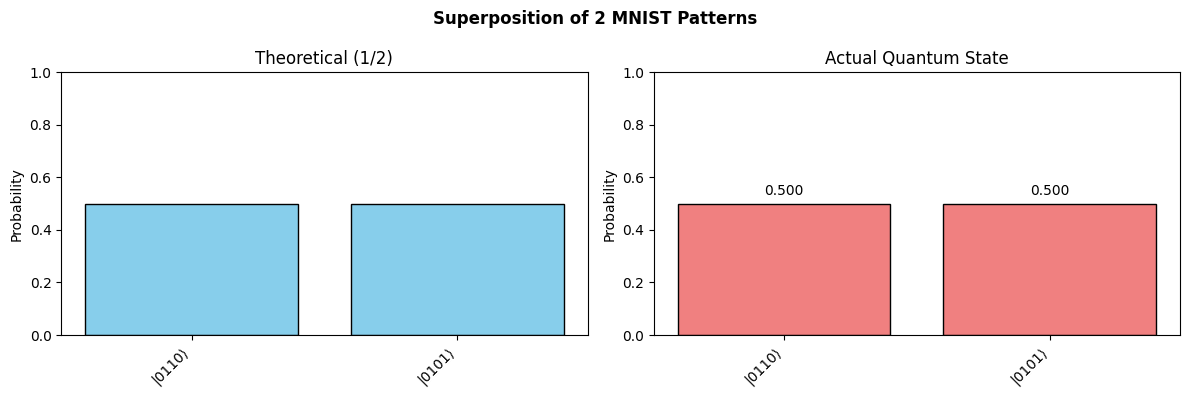

   |1.00.00.01.0⟩ (digit: 1)

Total unique patterns found: 3

Superposition of 2 MNIST Patterns

Encoded patterns:
   1. |0110⟩
   2. |0101⟩

Probabilities:
    |0110⟩: 0.5000 (expected: 0.5000)
    |0101⟩: 0.5000 (expected: 0.5000)

Total probability in patterns: 1.0000

SUCCESS! Superposition prepared correctly.


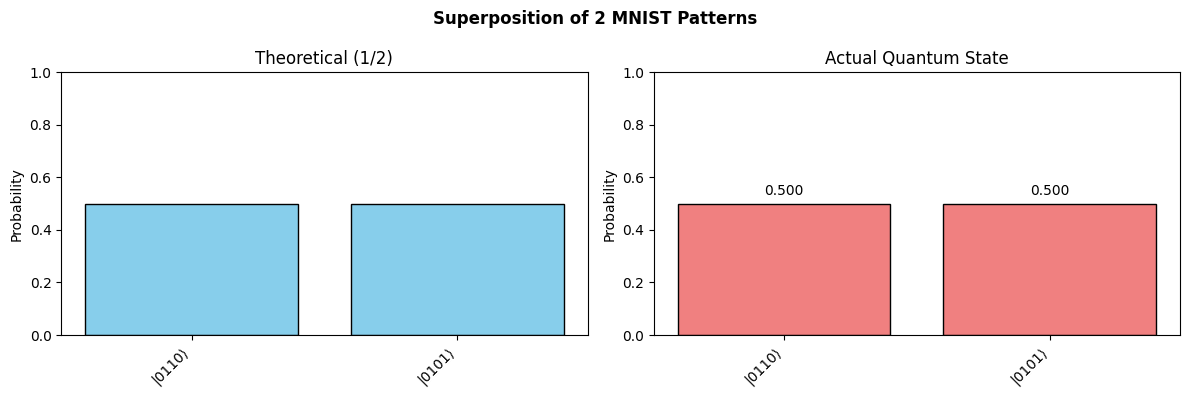


Superposition of 3 MNIST Patterns

Encoded patterns:
   1. |0110⟩
   2. |0101⟩
   3. |1001⟩

Probabilities:
    |0110⟩: 0.3333 (expected: 0.3333)
    |0101⟩: 0.3333 (expected: 0.3333)
    |1001⟩: 0.3333 (expected: 0.3333)

Total probability in patterns: 1.0000

SUCCESS! Superposition prepared correctly.


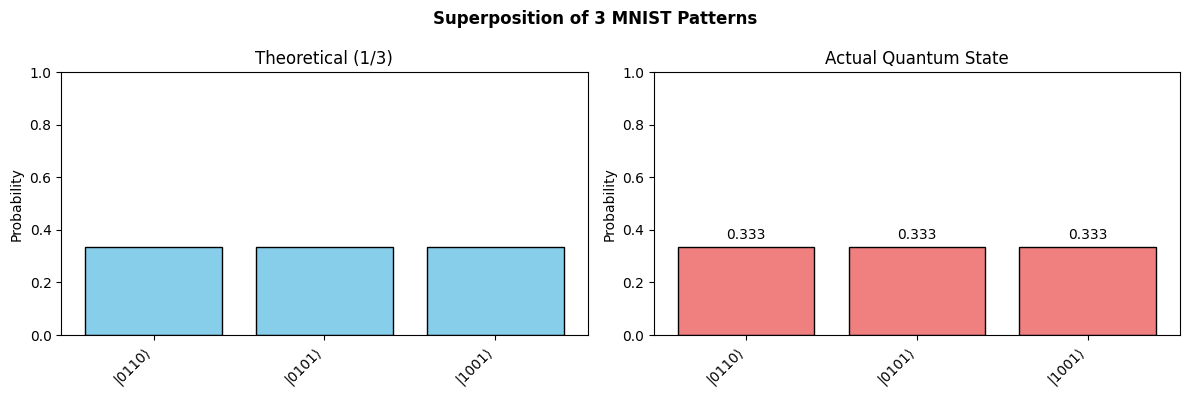

In [ ]:
(train_images, train_labels), _ = load_mnist_data(20, 0)
mask = (train_labels == 0) | (train_labels == 1)
train_images = train_images[mask][:20]
train_labels = train_labels[mask][:20]
X_reduced = reduce_dimensionality(train_images, N_QUBITS)
for i in range(len(X_reduced)):
    median = np.median(X_reduced[i])
    X_reduced[i] = (X_reduced[i] > median).astype(int)
print(f"\nMNIST data prepared: {len(X_reduced)} samples")
print(f"Each image reduced to {N_QUBITS} bits\n")

encoder = SuperpositionEncoder(n_qubits=N_QUBITS)

unique_patterns = []
seen = set()
print("\nUnique patterns found in MNIST:")
for i, p in enumerate(X_reduced):
    pattern_str = ''.join(str(b) for b in p)
    if pattern_str not in seen:
        seen.add(pattern_str)
        unique_patterns.append(p)
        print(f"   |{pattern_str}⟩ (digit: {train_labels[i]})")
        if len(unique_patterns) == 4:
            break
    print(f"\nTotal unique patterns found: {len(unique_patterns)}")
    if len(unique_patterns) >= 2:
        encoder.visualize(unique_patterns[:2], "Superposition of 2 MNIST Patterns")
    if len(unique_patterns) >= 3:
        encoder.visualize(unique_patterns[:3], "Superposition of 3 MNIST Patterns")
    if len(unique_patterns) >= 4:
        encoder.visualize(unique_patterns[:4], "Superposition of 4 MNIST Patterns")


# Preparação de Estados Arbitrários para Codificação por Amplitude

In [ ]:
dev = qml.device("default.qubit", wires=2)

In [ ]:
@qml.qnode(dev, interface="torch")
def quantum_circuit(feature):
  qml.AmplitudeEmbedding(features=feature, wires=[0,1], normalize=True)
  return qml.probs(wires=[0,1])

In [ ]:
X_tensor = torch.tensor([2.0, 4.0, 1.0, 3.0], requires_grad=True)
prob = quantum_circuit(X_tensor)
print("Measured Probabilities P(00), P(01), P(10), P(11):")
print(prob)

Measured Probabilities P(00), P(01), P(10), P(11):
tensor([0.1333, 0.5333, 0.0333, 0.3000], grad_fn=<ViewBackward0>)


## Preparação de Estados Eficiente em Amplitude

Preparação do estado:




$|\psi\rangle = \sqrt{0.2}|000\rangle + 0 + \sqrt{0.5}|010\rangle + 0 + 0 + 0 + \sqrt{0.2}|110\rangle + \sqrt{0.1}|111\rangle$




*   Probabilidade de $|000\rangle = (\sqrt{0.2})^2 = 0.2 → 20\% $
*   Probabilidade de $|010\rangle = (\sqrt{0.5})^2 = 0.5 → 50\% $
*   Probabilidade de $|110\rangle = (\sqrt{0.2})^2 = 0.2 → 20\% $
*   Probabilidade de $|111\rangle = (\sqrt{0.1})^2 = 0.1 → 10\% $







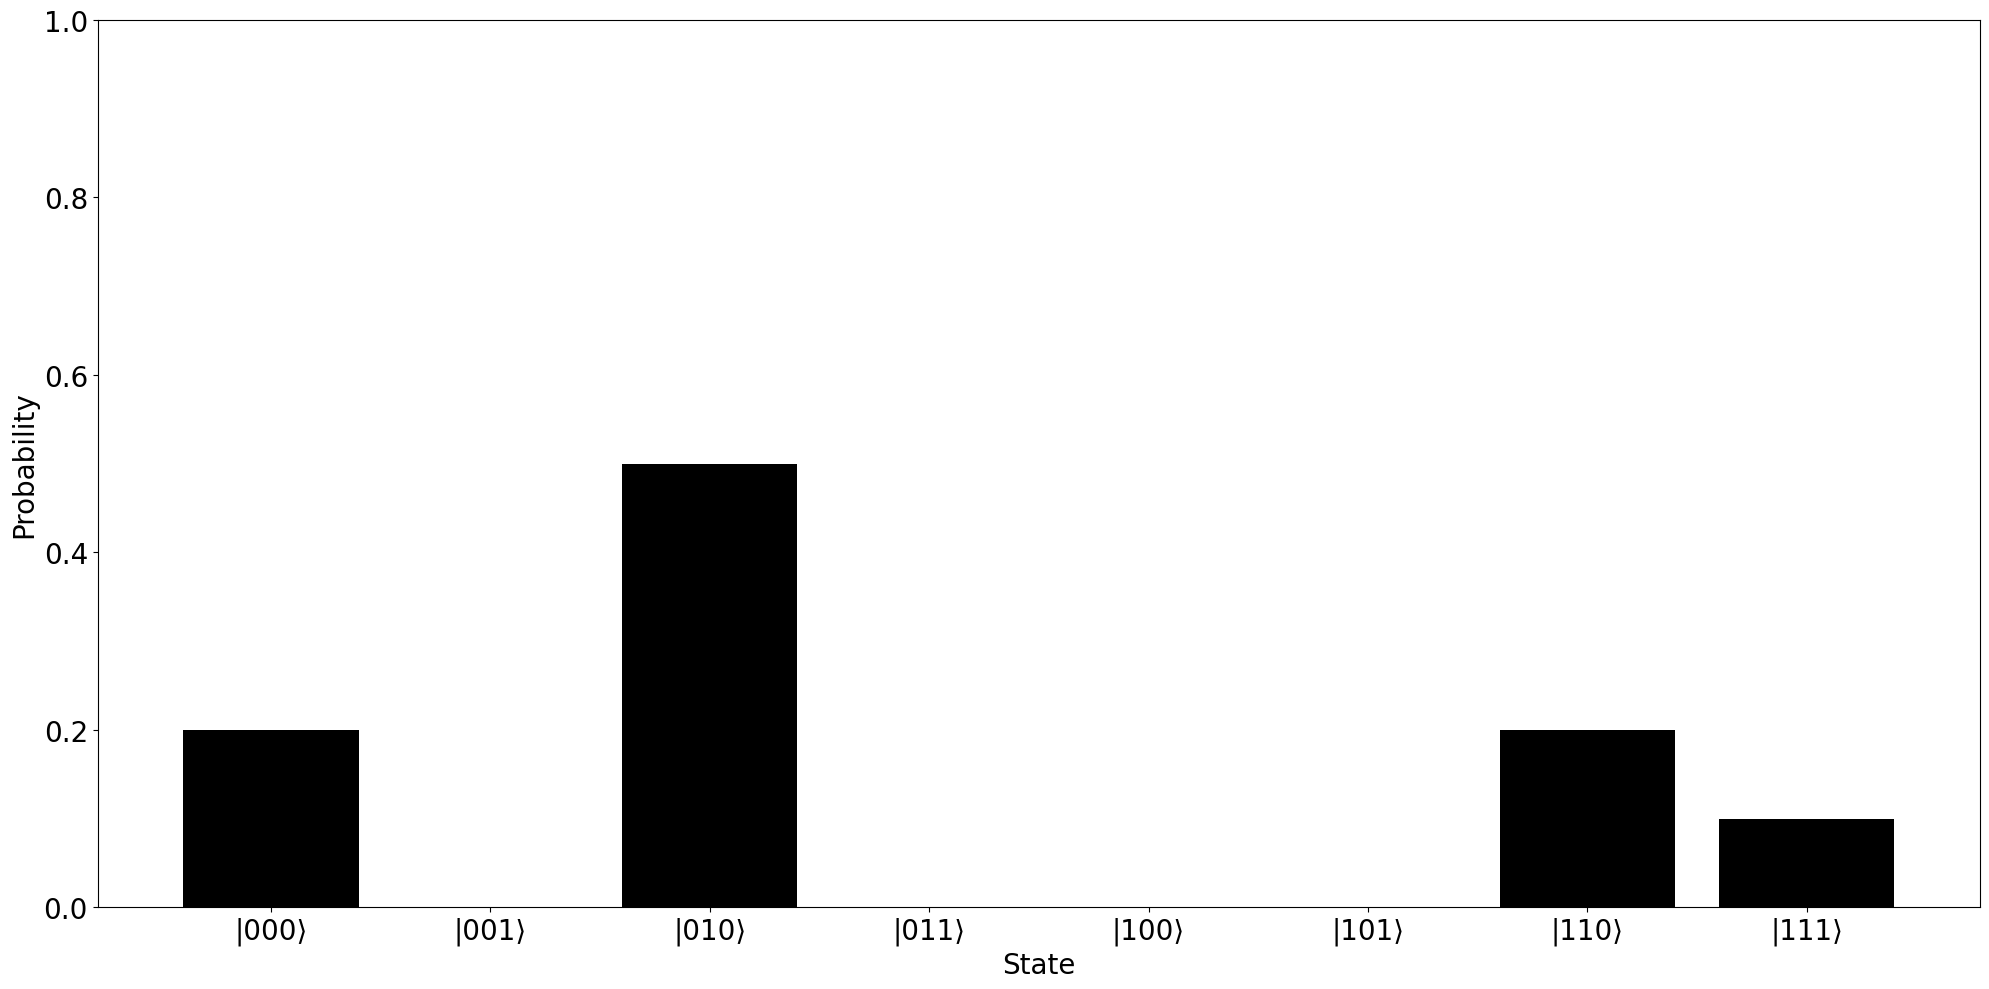

In [ ]:
state = ["|000⟩", "|001⟩", "|010⟩", "|011⟩", "|100⟩", "|101⟩", "|110⟩", "|111⟩"]
data = [np.sqrt(0.2), 0, np.sqrt(0.5), 0, 0, 0, np.sqrt(0.2), np.sqrt(0.1)]
state_vector = np.array(data)
norma = np.linalg.norm(state_vector)
probabilities = state_vector**2

plt.figure(figsize=(20,10))
plt.bar(state, probabilities, color='black')
plt.ylim(0, 1)
plt.ylabel("Probability", fontsize=20)
plt.xlabel("State", fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.show()

A escolha dos ângulos de rotação $\beta$ está relacionada às amplitudes (positivas) do estado original da seguinte forma:

$$
\beta_j^{\,s}
=
2\arcsin\left(
\sqrt{
\frac{
\sum_{l=1}^{2^{s-1}}
\left|\alpha_{(2j-1)2^{s-1}+l}\right|^2
}{
\sum_{l=1}^{2^{s}}
\left|\alpha_{(j-1)2^{s}+l}\right|^2
}
}
\right)
$$

- Numerador: $(\text{Soma superior})^2 \rightarrow q_n = 1$
- Denominador: $(\text{Soma total})^2 \rightarrow q_n = 0$ e $q_n = 1$

$$
c_{q_1}=0,\; c_{q_2}=0 \;\rightarrow\; R_y^{q_3}(\beta_1^1) \qquad \beta_1^1 = 0
$$

$$
c_{q_1}=0,\; c_{q_2}=1 \;\rightarrow\; R_y^{q_3}(\beta_2^1) \qquad \beta_2^1 = 0
$$

$$
c_{q_1}=1,\; c_{q_2}=0 \;\rightarrow\; R_y^{q_3}(\beta_3^1) \qquad \beta_3^1 = 0
$$

$$
c_{q_1}=1,\; c_{q_2}=1 \;\rightarrow\; R_y^{q_3}(\beta_4^1) \qquad \beta_4^1 = 1.231\ldots
$$

$$
c_{q_1}=0 \;\rightarrow\; R_y^{q_2}(\beta_1^2),\qquad \beta_1^2 = 2.014\ldots
$$

$$
c_{q_1}=1 \;\rightarrow\; R_y^{q_2}(\beta_2^2), \qquad \beta_2^2 = 3.142\ldots
$$

$$
R_y^{q_1}(\beta_1^3), \qquad \beta_1^3 = 1.159\ldots
$$

In [ ]:
def compute_beta(prob_rama, prob_total):
  if prob_total == 0:
    return 0.0
  return 2*np.arcsin(np.sqrt(prob_rama / prob_total))

In [ ]:
print("Algoritmo de Möttönen")

"""
Level 3: Sheets (Qubit 3, Controlled by Q1 and Q2)
"""
beta_q3_00 = compute_beta(probabilities[1], sum(probabilities[0:2]))
beta_q3_01 = compute_beta(probabilities[3], sum(probabilities[2:4]))
beta_q3_10 = compute_beta(probabilities[5], sum(probabilities[4:6]))
beta_q3_11 = compute_beta(probabilities[7], sum(probabilities[6:8]))

print(f"Beta Q3 (Q1=0, Q2=0): {beta_q3_00:.3f} rad")
print(f"Beta Q3 (Q1=0, Q2=1): {beta_q3_01:.3f} rad")
print(f"Beta Q3 (Q1=1, Q2=0): {beta_q3_10:.3f} rad")
print(f"Beta Q3 (Q1=1, Q2=1): {beta_q3_11:.3f} rad")

"""
Level 2: Branch (Qubit 2, Controlled by Q1)
"""
# if Q1 = 0
prob_q2_ctrl0_total = sum(probabilities[0:4])
prob_q2_ctrl0_rama = sum(probabilities[2:4])
beta_q2_ctrl0 = compute_beta(prob_q2_ctrl0_rama, prob_q2_ctrl0_total)
print(f"Beta Q2 (Q1=0): {beta_q2_ctrl0:.3f} rad")

# if Q1 = 1
prob_q2_ctrl1_total = sum(probabilities[4:8])
prob_q2_ctrl1_rama = sum(probabilities[6:8])
beta_q2_ctrl1 = compute_beta(prob_q2_ctrl1_rama, prob_q2_ctrl1_total)
print(f"Beta Q2 (Q1=1): {beta_q2_ctrl1:.3f} rad")

"""
Level 1: Root (Qubit 1, Without Control)
"""
prob_q1_total = sum(probabilities[0:8])
prob_q1_rama = sum(probabilities[4:8])
beta_q1 = compute_beta(prob_q1_rama, prob_q1_total)
print(f"Beta Q1 (Without control): {beta_q1:.3f} rad")

Algoritmo de Möttönen
Beta Q3 (Q1=0, Q2=0): 0.000 rad
Beta Q3 (Q1=0, Q2=1): 0.000 rad
Beta Q3 (Q1=1, Q2=0): 0.000 rad
Beta Q3 (Q1=1, Q2=1): 1.231 rad
Beta Q2 (Q1=0): 2.014 rad
Beta Q2 (Q1=1): 3.142 rad
Beta Q1 (Without control): 1.159 rad


In [ ]:
from qiskit.circuit.library import RYGate

print("Building the Cirtuit")
qc = QuantumCircuit(3)

if beta_q1 > 0:
  qc.ry(beta_q1.item(), 0)

if beta_q2_ctrl0 > 0:
    ry = RYGate(beta_q2_ctrl0.item()).control(1, ctrl_state='0')
    qc.append(ry, [0, 1])
if beta_q2_ctrl1 > 0:
    ry = RYGate(beta_q2_ctrl1.item()).control(1, ctrl_state='1')
    qc.append(ry, [0, 1])
if beta_q3_00 > 0:
    ry = RYGate(beta_q3_00.item()).control(2, ctrl_state='00')
    qc.append(ry, [0, 1, 2])
if beta_q3_01 > 0:
    ry = RYGate(beta_q3_01.item()).control(2, ctrl_state='01')
    qc.append(ry, [0, 1, 2])
if beta_q3_10 > 0:
    ry = RYGate(beta_q3_10.item()).control(2, ctrl_state='10')
    qc.append(ry, [0, 1, 2])
if beta_q3_11 > 0:
    ry = RYGate(beta_q3_11.item()).control(2, ctrl_state='11')
    qc.append(ry, [0, 1, 2])

print(qc.draw('text'))

Building the Cirtuit
     ┌────────────┐                                    
q_0: ┤ Ry(1.1593) ├──────o───────────■──────────■──────
     └────────────┘┌─────┴──────┐┌───┴───┐      │      
q_1: ──────────────┤ Ry(2.0137) ├┤ Ry(π) ├──────■──────
                   └────────────┘└───────┘┌─────┴─────┐
q_2: ─────────────────────────────────────┤ Ry(1.231) ├
                                          └───────────┘


# Preparação de Estados Eficiente em Qubits

In [ ]:
"""
Esquema de Soklakov e Schack (Amplificação de Amplitude)
"""

qc = QuantumCircuit(3)

"""
PASSO 1: Sobreposição Uniforme (Ruído Branco de Fundo)
Aplicamos portas de Hadamard a todos os qubits
Isso dá a cada um dos 8 estados (000 a 111) uma probabilidade de 12,5%.
"""
qc.h([0,1,2])
qc.barrier()

"""
PASSO 2: O Oráculo (Marcando a Falha Mecânica)
Queremos marcar o estado |101> (q2=1, q1=0, q0=1 no Qiskit).
O oráculo inverte a fase (o sinal) desse estado específico.
Para ativar o Multi-Controlled Gate (CCZ) apenas em |101>,
aplicamos X portas NOT ao qubit que deve ser 0.
"""
qc.x(1)
qc.h(2)
qc.ccx(0,1,2)
qc.h(2)
qc.x(1)
qc.barrier()

"""
PASSO 3: Difusor de Grover (Amplificação de Amplitude)
Esta sequência realiza uma "Inversão da Média".
Ela pega o estado marcado pelo oráculo e amplifica drasticamente sua
probabilidade.
"""
qc.h([0, 1, 2])
qc.x([0, 1, 2])

qc.h(2)
qc.ccx(0, 1, 2)
qc.h(2)

qc.x([0, 1, 2])
qc.h([0, 1, 2])

print(qc.draw('text'))

     ┌───┐ ░                 ░ ┌───┐┌───┐          ┌───┐┌───┐     
q_0: ┤ H ├─░────────■────────░─┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
     ├───┤ ░ ┌───┐  │  ┌───┐ ░ ├───┤├───┤       │  ├───┤├───┤     
q_1: ┤ H ├─░─┤ X ├──■──┤ X ├─░─┤ H ├┤ X ├───────■──┤ X ├┤ H ├─────
     ├───┤ ░ ├───┤┌─┴─┐├───┤ ░ ├───┤├───┤┌───┐┌─┴─┐├───┤├───┤┌───┐
q_2: ┤ H ├─░─┤ H ├┤ X ├┤ H ├─░─┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├
     └───┘ ░ └───┘└───┘└───┘ ░ └───┘└───┘└───┘└───┘└───┘└───┘└───┘


In [ ]:
print("\n--- Distribuição de probabilidade ---")
estado_final = Statevector(qc)
probabilidades = estado_final.probabilities()

for i, prob in enumerate(probabilidades):
    estado_binario = format(i, '03b')[::-1] # Formato q0 q1 q2
    print(f"Estado |{estado_binario}> : {prob*100:.1f}%")


--- Distribuição de probabilidade ---
Estado |000> : 3.1%
Estado |100> : 3.1%
Estado |010> : 3.1%
Estado |110> : 3.1%
Estado |001> : 3.1%
Estado |101> : 78.1%
Estado |011> : 3.1%
Estado |111> : 3.1%


# Codificação de Entradas como Evoluções no Tempo

In [ ]:
sample = [1.57, 0.78, -1.5, -0.25]

qubits = len(sample)

qc_encoding = QuantumCircuit(qubits)
for i, features in enumerate(sample):
  qc_encoding.ry(features, i)

print(qc_encoding.draw('text'))

codified_state = Statevector(qc_encoding)
for i, amplitude in enumerate(codified_state.data):
  binary_state = format(i, f'0{qubits}b')[::-1]
  if abs(amplitude) > 0.001:
    print(f"State Amplitude: |{binary_state}>: {amplitude.real:.4f}")


      ┌──────────┐
q_0: ─┤ Ry(1.57) ├
      ├──────────┤
q_1: ─┤ Ry(0.78) ├
      ├──────────┤
q_2: ─┤ Ry(-1.5) ├
     ┌┴──────────┤
q_3: ┤ Ry(-0.25) ├
     └───────────┘
State Amplitude: |0000>: 0.4750
State Amplitude: |1000>: 0.4746
State Amplitude: |0100>: 0.1952
State Amplitude: |1100>: 0.1951
State Amplitude: |0010>: -0.4425
State Amplitude: |1010>: -0.4421
State Amplitude: |0110>: -0.1819
State Amplitude: |1110>: -0.1817
State Amplitude: |0001>: -0.0597
State Amplitude: |1001>: -0.0596
State Amplitude: |0101>: -0.0245
State Amplitude: |1101>: -0.0245
State Amplitude: |0011>: 0.0556
State Amplitude: |1011>: 0.0556
State Amplitude: |0111>: 0.0229
State Amplitude: |1111>: 0.0228



# Codificação de um Conjunto de Dados via Hamiltoniano


## Simulação de Hamiltonianos

In [ ]:
matriz = np.array([
                    [2.5, 0.7, 0.8],
                    [0.7, 0.8, 1.5],
                    [0.8, 1.5, 1.5]
                  ])
matriz = np.pad(matriz, ((0, 1), (0, 1)), mode='constant')
print(matriz)

is_herm = np.allclose(matriz, matriz.conj().T)
if not is_herm:
  raise ValueError("A matriz não é hermitiana.")

operator = Operator(matriz)
hamiltonian = SparsePauliOp.from_operator(operator)

for pauli, coef in zip(hamiltonian.paulis, hamiltonian.coeffs):
  print(f"h_{pauli} = {coef.real:.3f}")

print("Result")
print(f"H = {hamiltonian}")

[[2.5 0.7 0.8 0. ]
 [0.7 0.8 1.5 0. ]
 [0.8 1.5 1.5 0. ]
 [0.  0.  0.  0. ]]
h_II = 1.200
h_IX = 0.350
h_IZ = 0.800
h_XI = 0.400
h_XX = 0.750
h_XZ = 0.400
h_YY = 0.750
h_ZI = 0.450
h_ZX = 0.350
h_ZZ = 0.050
Result
H = SparsePauliOp(['II', 'IX', 'IZ', 'XI', 'XX', 'XZ', 'YY', 'ZI', 'ZX', 'ZZ'],
              coeffs=[1.2 +0.j, 0.35+0.j, 0.8 +0.j, 0.4 +0.j, 0.75+0.j, 0.4 +0.j, 0.75-0.j,
 0.45+0.j, 0.35+0.j, 0.05+0.j])


# Simulação de Hamiltonianos Eficiente em Qubits

In [ ]:
num_q = 4
dimension = 2**num_q

"""
First Case
"""
dense_matrix = np.random.rand(dimension, dimension)
dense_matrix = (dense_matrix + dense_matrix.T) / 2

operator = Operator(dense_matrix)
pauli = SparsePauliOp.from_operator(operator)
terms = sum(1 for c in pauli.coeffs if abs(c) > 1e-10)

print(f"Requirements for the matrix {terms} Pauli's Gates to be simulated")
print(f"4^{num_q} = {4**num_q}")

Requirements for the matrix 136 Pauli's Gates to be simulated
4^4 = 256


In [ ]:
"""
Second Case
"""
S_matrix = np.zeros((dimension, dimension))
np.fill_diagonal(S_matrix, np.random.rand(dimension))

# There are high interaction between the features 2 and 14

S_matrix[2, 14] = 0.85
S_matrix[14, 2] = 0.85

S_operator = Operator(S_matrix)
S_pauli = SparsePauliOp.from_operator(S_operator)
S_terms = sum(1 for c in S_pauli.coeffs if abs(c) > 1e-10)

print(f"Requirements for the matrix {S_terms} Pauli's Gates to be simulated")

Requirements for the matrix 24 Pauli's Gates to be simulated


# Exponenciação da Matriz Densidade

In [ ]:
import numpy as np
from scipy.linalg import expm

def partial_trace_2nd_subsystem(joint_matrix, dim1, dim2):
    """
    Takes the partial trace over the second subsystem.
    Assumes a bipartite system of dimensions dim1 and dim2.
    """
    # Reshape the 4D tensor: (dim1, dim2, dim1, dim2)
    reshaped = joint_matrix.reshape(dim1, dim2, dim1, dim2)
    # Trace over the second subsystem (axis 1 and 3)
    return np.trace(reshaped, axis1=1, axis2=3)

# 1. Define Pauli matrices to generate arbitrary states
I = np.eye(2)
X = np.array([[0, 1], [1, 0]])
Z = np.array([[1, 0], [0, -1]])

# 2. Create arbitrary mixed states rho and sigma (must be positive semi-definite, trace=1)
rho_unnormalized = I + 0.5 * Z + 0.5 * X
rho = rho_unnormalized / np.trace(rho_unnormalized)

sigma_unnormalized = I - 0.3 * Z + 0.8 * X
sigma = sigma_unnormalized / np.trace(sigma_unnormalized)

# 3. Define the SWAP operator for two qubits
SWAP = np.array([[1, 0, 0, 0],
                 [0, 0, 1, 0],
                 [0, 1, 0, 0],
                 [0, 0, 0, 1]])

# Small time step (Delta t)
dt = 0.05

# ---------------------------------------------------------
# METHOD 1: The SWAP Trick (Left-hand side of Eq 4.70)
# tr_2 { exp(-i S dt) (sigma \otimes rho) exp(i S dt) }
# ---------------------------------------------------------

# Create the joint initial state (sigma tensor rho)
joint_state = np.kron(sigma, rho)

# Simulate the SWAP evolution for time dt
U_swap = expm(-1j * SWAP * dt)
U_swap_dag = expm(1j * SWAP * dt)

evolved_joint_state = U_swap @ joint_state @ U_swap_dag

# Trace out the second system (rho) to see what happens to sigma
sigma_LHS = partial_trace_2nd_subsystem(evolved_joint_state, dim1=2, dim2=2)

# ---------------------------------------------------------
# METHOD 2: Direct Exponentiation (Right-hand side of Eq 4.70)
# exp(-i rho dt) sigma exp(i rho dt)
# ---------------------------------------------------------

U_rho = expm(-1j * rho * dt)
U_rho_dag = expm(1j * rho * dt)

sigma_RHS = U_rho @ sigma @ U_rho_dag

# ---------------------------------------------------------
# Compare the results
# ---------------------------------------------------------

print("Result from Partial Trace of SWAP evolution:\n", np.round(sigma_LHS, 4))
print("\nResult from Direct Exponentiation of rho:\n", np.round(sigma_RHS, 4))

# Calculate the Frobenius norm of the difference
error = np.linalg.norm(sigma_LHS - sigma_RHS)
print(f"\nDifference matrix norm: {error:.6f}")
print(f"O(dt^2) theoretical error bounds: {dt**2:.6f}")

Result from Partial Trace of SWAP evolution:
 [[0.351 +0.j     0.3996-0.0137j]
 [0.3996+0.0137j 0.649 -0.j    ]]

Result from Direct Exponentiation of rho:
 [[0.3502+0.j     0.3998-0.0137j]
 [0.3998+0.0137j 0.6498+0.j    ]]

Difference matrix norm: 0.001205
O(dt^2) theoretical error bounds: 0.002500
